# Лабораторная работа 2: Классификация
---

In [ ]:
!pip install catboost

In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

In [ ]:
pd.options.display.float_format = '{:.6f}'.format
pd.set_option("display.precision", 2)
pd.set_option('display.max_columns', None)
train_df = pd.read_csv("/content/train.csv")

## Проанализируем данные

### Датасет

In [ ]:
train_df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.000000,66829.000000,549.000000,17290.000000,60.000000,Divorced,1.000000,Rent,1095.000000,0.151985,2.000000,1.000000,0.168542,0.000000,Education,0.000000,23.000000,5.000000,2539.000000,247.000000,50072.000000,15005.000000,5569.083333,0.908289,4.000000,Employed,Associate,4.000000,35067.000000,0.257790,0.251465,508.970230,0.288013,0.000000,66.176500
1,1996-09-23,55.000000,172147.000000,850.000000,16110.000000,36.000000,Widowed,1.000000,Mortgage,211.000000,0.175693,3.000000,0.000000,0.141553,0.000000,Home,0.000000,27.000000,11.000000,844.000000,694.000000,91878.000000,64877.000000,14345.583333,0.797339,2.000000,Employed,High School,33.000000,27001.000000,0.086110,0.093173,514.675859,0.050585,1.000000,28.495737
2,2015-01-19,51.000000,300000.000000,850.000000,38436.000000,36.000000,Married,0.000000,Mortgage,546.000000,0.444605,3.000000,0.000000,0.030987,1.000000,Education,0.000000,21.000000,12.000000,12756.000000,651.000000,292300.000000,13918.000000,25000.000000,0.915945,3.000000,Employed,Bachelor,28.000000,278382.000000,0.108436,0.115443,1268.276385,0.072571,1.000000,34.488104
3,1981-05-12,25.000000,34683.000000,847.000000,19186.000000,48.000000,Married,0.000000,Other,153.000000,0.188452,7.000000,0.000000,0.379843,0.000000,Debt Consolidation,0.000000,27.000000,21.000000,1524.000000,529.000000,13070.000000,3846.000000,2890.250000,0.876416,3.000000,Employed,High School,0.000000,9224.000000,0.100686,0.112822,498.505187,0.225415,1.000000,36.910753
4,1995-05-07,55.000000,300000.000000,850.000000,30437.000000,48.000000,Single,2.000000,Rent,562.000000,0.273431,3.000000,1.000000,0.068659,0.000000,Debt Consolidation,0.000000,35.000000,9.000000,1973.000000,128.000000,33357.000000,351603.000000,25000.000000,0.888689,5.000000,Employed,Bachelor,31.000000,4502.000000,0.110437,0.089037,756.035156,0.052721,1.000000,31.347091


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

### Значения важной фичи

In [ ]:
train_df['RiskScore'].value_counts()

,count
RiskScore,
-9999999.000000,121
10000000.000000,94
65.540564,3
67.850406,3
35.133282,3
...,...
55.866106,1
36.507778,1
46.625660,1


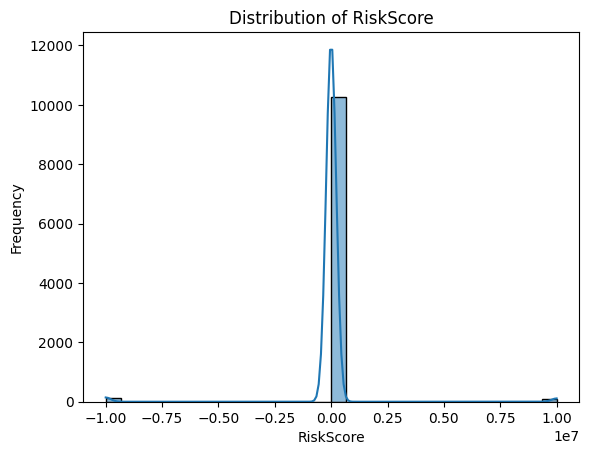

In [ ]:
sns.histplot(train_df['RiskScore'], bins=30, kde=True)
plt.title('Distribution of RiskScore')
plt.xlabel('RiskScore')
plt.ylabel('Frequency')
plt.show()

In [ ]:
train_df = train_df.loc[~train_df['RiskScore'].isin([-9999999.000000, 10000000.000000])]

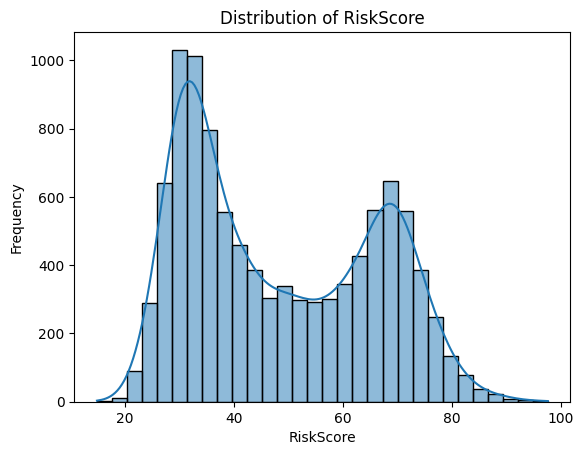

In [ ]:
sns.histplot(train_df['RiskScore'], bins=30, kde=True)
plt.title('Distribution of RiskScore')
plt.xlabel('RiskScore')
plt.ylabel('Frequency')
plt.show()

### Распределение таргета

In [ ]:
train_df['LoanApproved'].value_counts()

,count
LoanApproved,
1.000000,5257
0.000000,5015


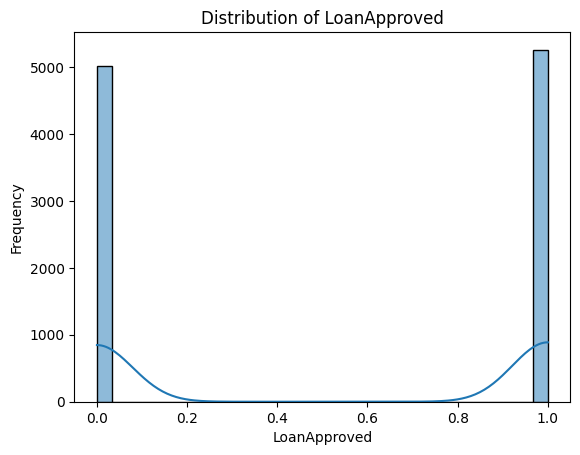

In [ ]:
sns.histplot(train_df['LoanApproved'], bins=30, kde=True)
plt.title('Distribution of LoanApproved')
plt.xlabel('LoanApproved')
plt.ylabel('Frequency')
plt.show()

### Посмотрим на пропуски в данных

In [ ]:
def missing_values_table(df):
        mis_val = df.isnull().sum()
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        data_types = df.dtypes
        mis_val_table = pd.concat([mis_val, mis_val_percent, data_types], axis=1)
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values', 2: 'Data Type'})
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        print ("В выбранном датафрейме " + str(df.shape[1]) + " столбцов.\n"
            "Всего " + str(mis_val_table_ren_columns.shape[0]) +
              " столбцов с неполными данными.")
        return mis_val_table_ren_columns

missing_values = missing_values_table(train_df)
missing_values.head(12)

В выбранном датафрейме 36 столбцов.
Всего 36 столбцов с неполными данными.


,Missing Values,% of Total Values,Data Type
NetWorth,1015,9.400000,float64
BaseInterestRate,1015,9.400000,float64
LoanPurpose,1015,9.400000,object
BankruptcyHistory,1015,9.400000,float64
TotalAssets,1015,9.400000,float64
MonthlyDebtPayments,1015,9.400000,float64
CheckingAccountBalance,1015,9.400000,float64
LoanAmount,1015,9.400000,float64
CreditScore,1015,9.400000,float64
InterestRate,530,4.900000,float64


In [ ]:
rows_nan = train_df[train_df.isnull().all(axis=1)]
rows_nan.shape


(530, 36)

In [ ]:
train_df = train_df.dropna(how='all')

##### Пропуски остались

In [ ]:
columns_to_check = ['CreditScore', 'LoanAmount', 'MonthlyDebtPayments',
                    'BankruptcyHistory', 'LoanPurpose', 'CheckingAccountBalance',
                    'TotalAssets', 'NetWorth', 'BaseInterestRate']
train_df = train_df.dropna(subset=columns_to_check)

##### Пропуски почищены

In [ ]:
missing_values2 = missing_values_table(train_df)

В выбранном датафрейме 36 столбцов.
Всего 0 столбцов с неполными данными.


### Фильтрация данных

In [ ]:
train_df.describe(include=["object"])

,ApplicationDate,MaritalStatus,HomeOwnershipStatus,LoanPurpose,EmploymentStatus,EducationLevel
count,9787,9787,9787,9787,9787,9787
unique,9332,4,4,5,3,5
top,2011-04-20,Married,Mortgage,Home,Employed,High School
freq,3,4802,3872,2919,8470,3945


In [ ]:
train_df['ApplicationDate'] = pd.to_datetime(train_df['ApplicationDate'])
train_df['ApplicationMonth'] = train_df['ApplicationDate'].dt.month.astype(int)
train_df['BankruptcyHistory'] = train_df['BankruptcyHistory'].astype(int)
train_df['LoanAmount'] = train_df['LoanAmount'].astype(int)
train_df['PreviousLoanDefaults'] = train_df['PreviousLoanDefaults'].astype(int)
train_df = train_df.drop(columns=["ApplicationDate"])

In [ ]:
train_df.dtypes.value_counts()

,count
float64,27
object,5
int64,4


#### Категориальные признаки

In [ ]:
train_df.select_dtypes(include=[object]).apply(pd.Series.nunique, axis = 0)

,0
MaritalStatus,4
HomeOwnershipStatus,4
LoanPurpose,5
EmploymentStatus,3
EducationLevel,5


In [ ]:
def restruct(value):
    if value == "High School":
        return "A"
    elif value == "Bachelor":
        return "B"
    elif value == "Associate":
        return "C"
    elif value == "Master":
        return "D"
    elif value == "Doctorate":
        return "E"
    else:
        return "A"

train_df["EducationLevel"] = LabelEncoder().fit_transform(train_df["EducationLevel"].apply(restruct))
categorical_columns = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus']
train_df = pd.get_dummies(train_df, columns=categorical_columns, drop_first=True)
print('Формат тренировочной выборки: ', train_df.shape)

Формат тренировочной выборки:  (9787, 44)


#### Еще поработаем с данными

In [ ]:
train_df = train_df.rename(columns={'LoanApproved': 'TARGET'})

#### Корреляция данных

In [ ]:
correlationk = train_df.corr()['TARGET'].sort_values(ascending=False)
print(correlationk)

TARGET                            1.000000
MonthlyIncome                     0.754733
AnnualIncome                      0.742338
CreditScore                       0.581615
NetWorth                          0.129422
TotalAssets                       0.129180
EducationLevel                    0.064029
Experience                        0.037894
Age                               0.037894
LengthOfCreditHistory             0.033393
LoanPurpose_Debt Consolidation    0.017257
EmploymentStatus_Self-Employed    0.016379
DebtToIncomeRatio                 0.014760
NumberOfCreditInquiries           0.013212
HomeOwnershipStatus_Own           0.012946
CheckingAccountBalance            0.011494
LoanPurpose_Home                  0.008560
NumberOfOpenCreditLines           0.006574
MaritalStatus_Widowed             0.001553
CreditCardUtilizationRate         0.000520
ApplicationMonth                 -0.003825
HomeOwnershipStatus_Other        -0.004253
MaritalStatus_Single             -0.004350
JobTenure  

##### Построим тепловую карту

In [ ]:
ext_data = train_df[train_df.columns]
ext_data_corrs = ext_data.corr()

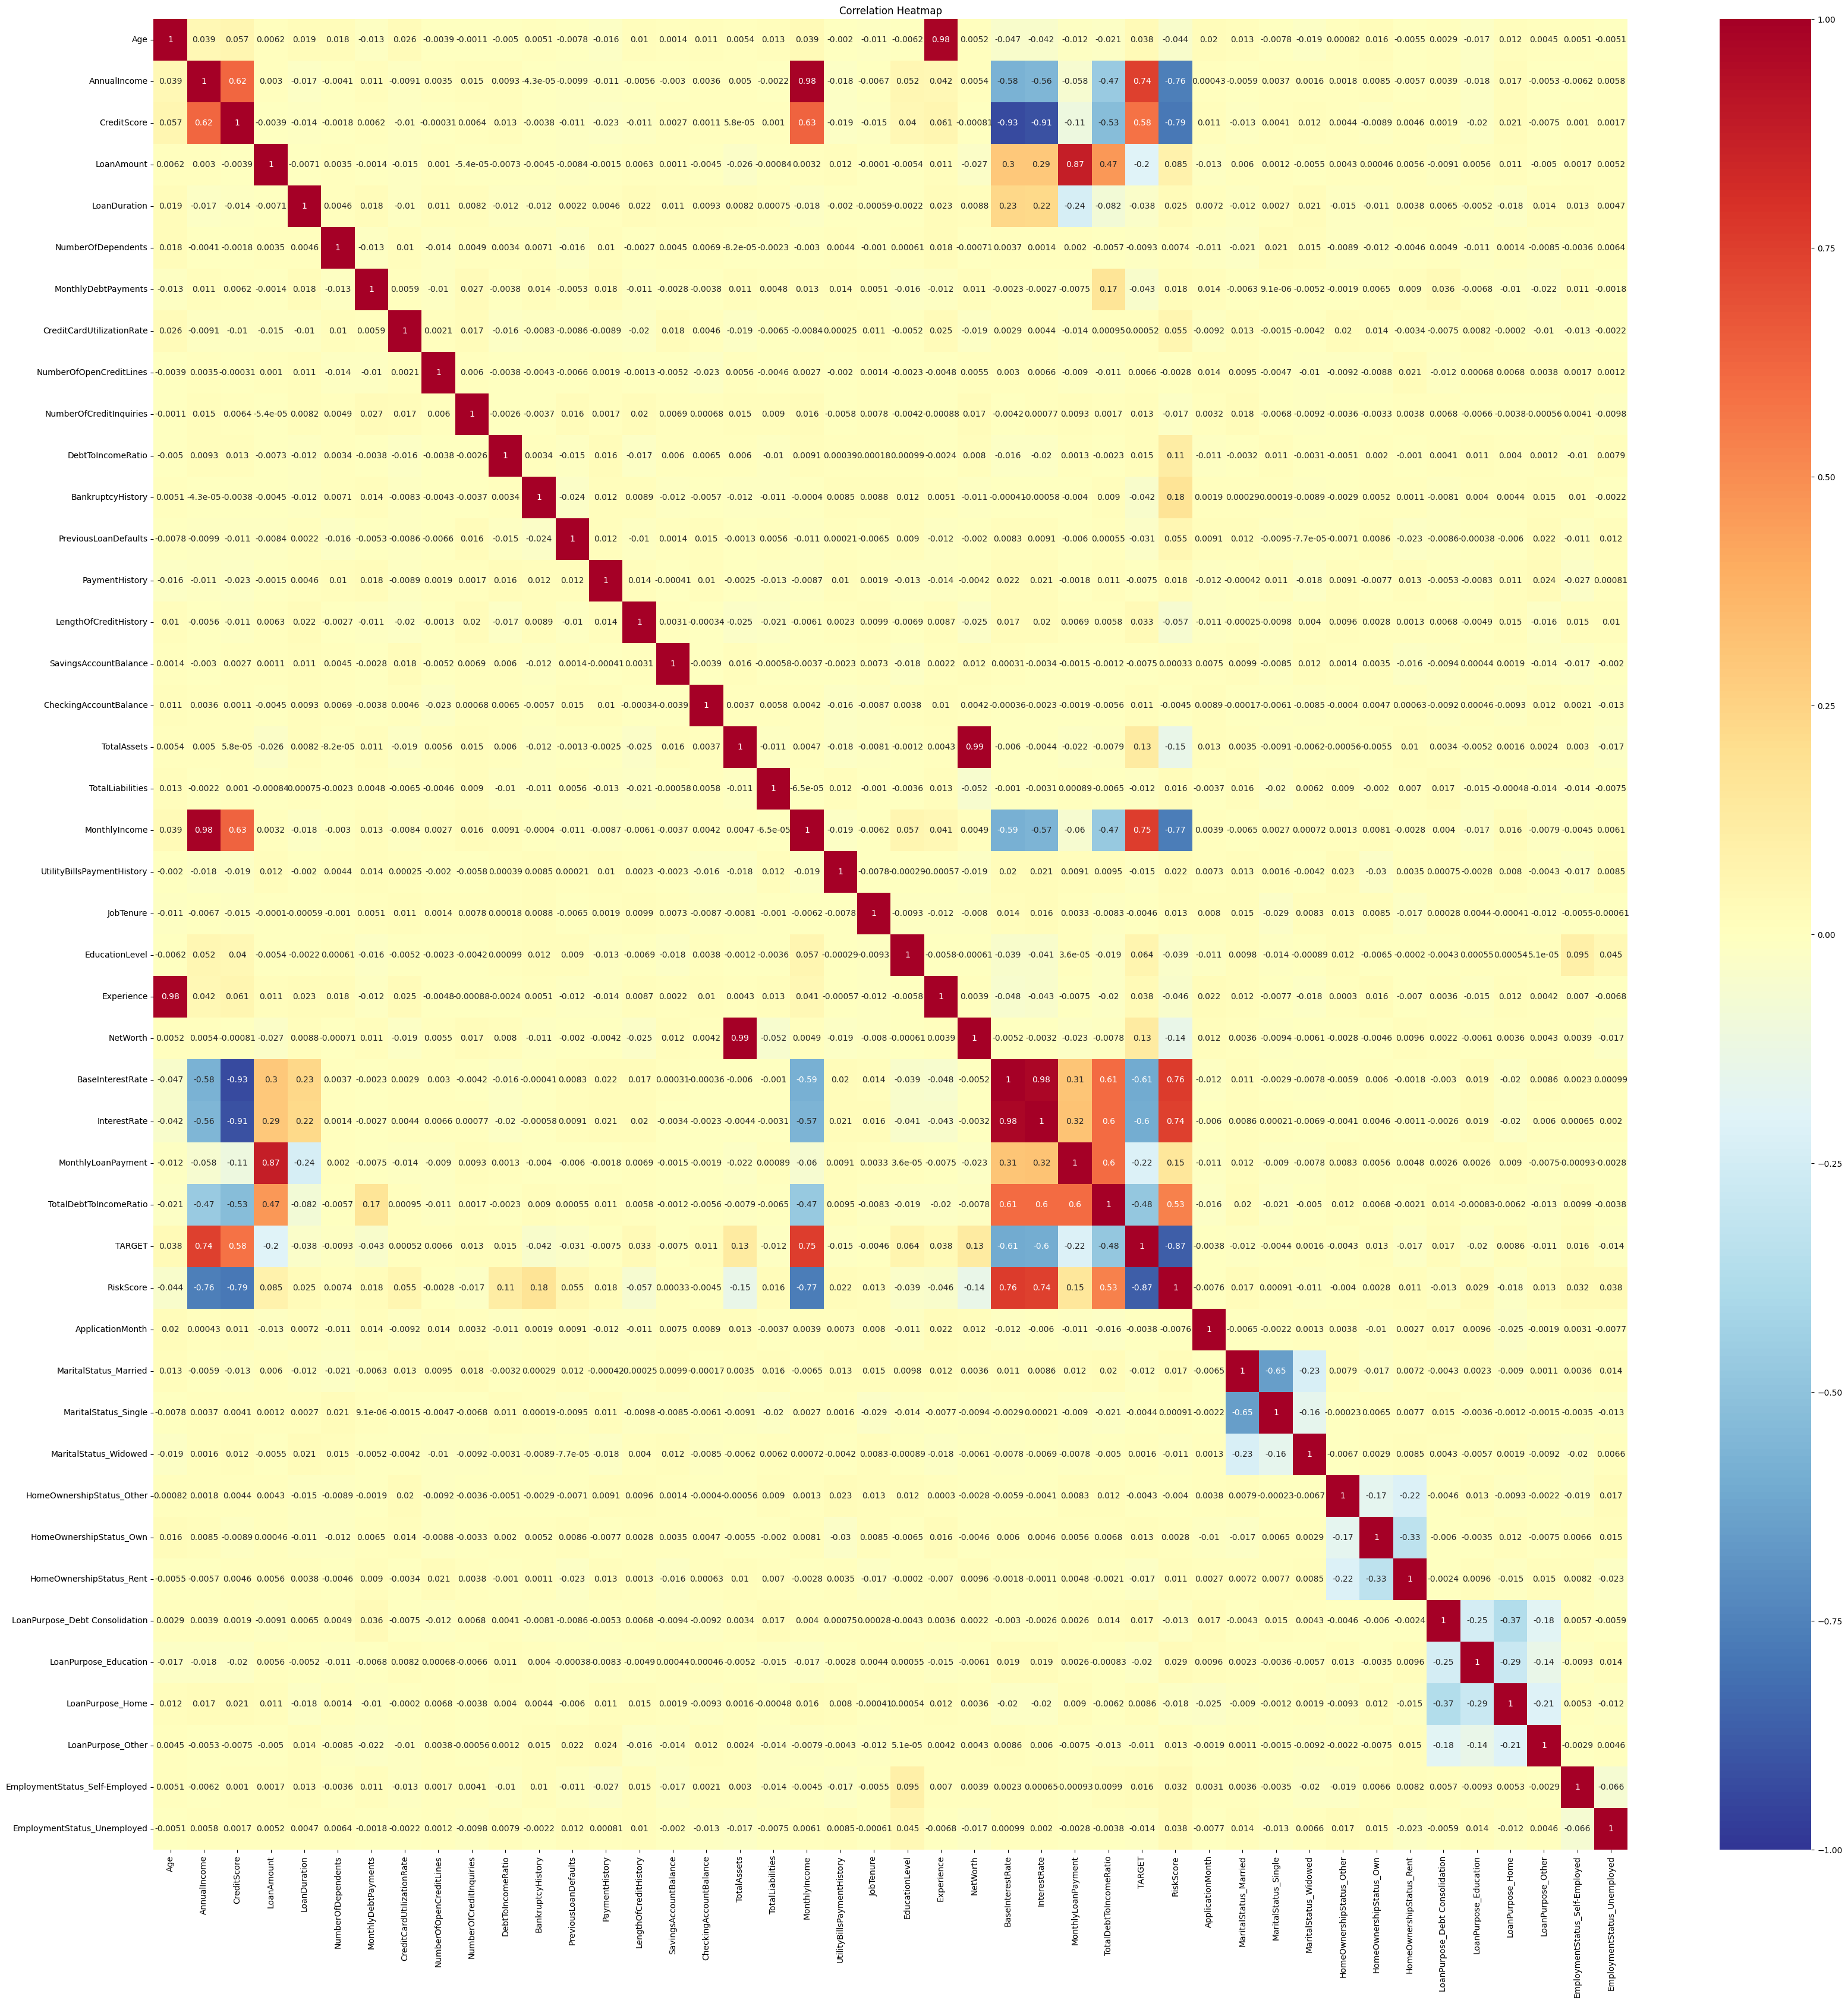

In [ ]:
plt.figure(figsize = (40, 40))
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -1, annot = True, vmax = 1)
plt.title('Correlation Heatmap');

#### Посмотрим на графики


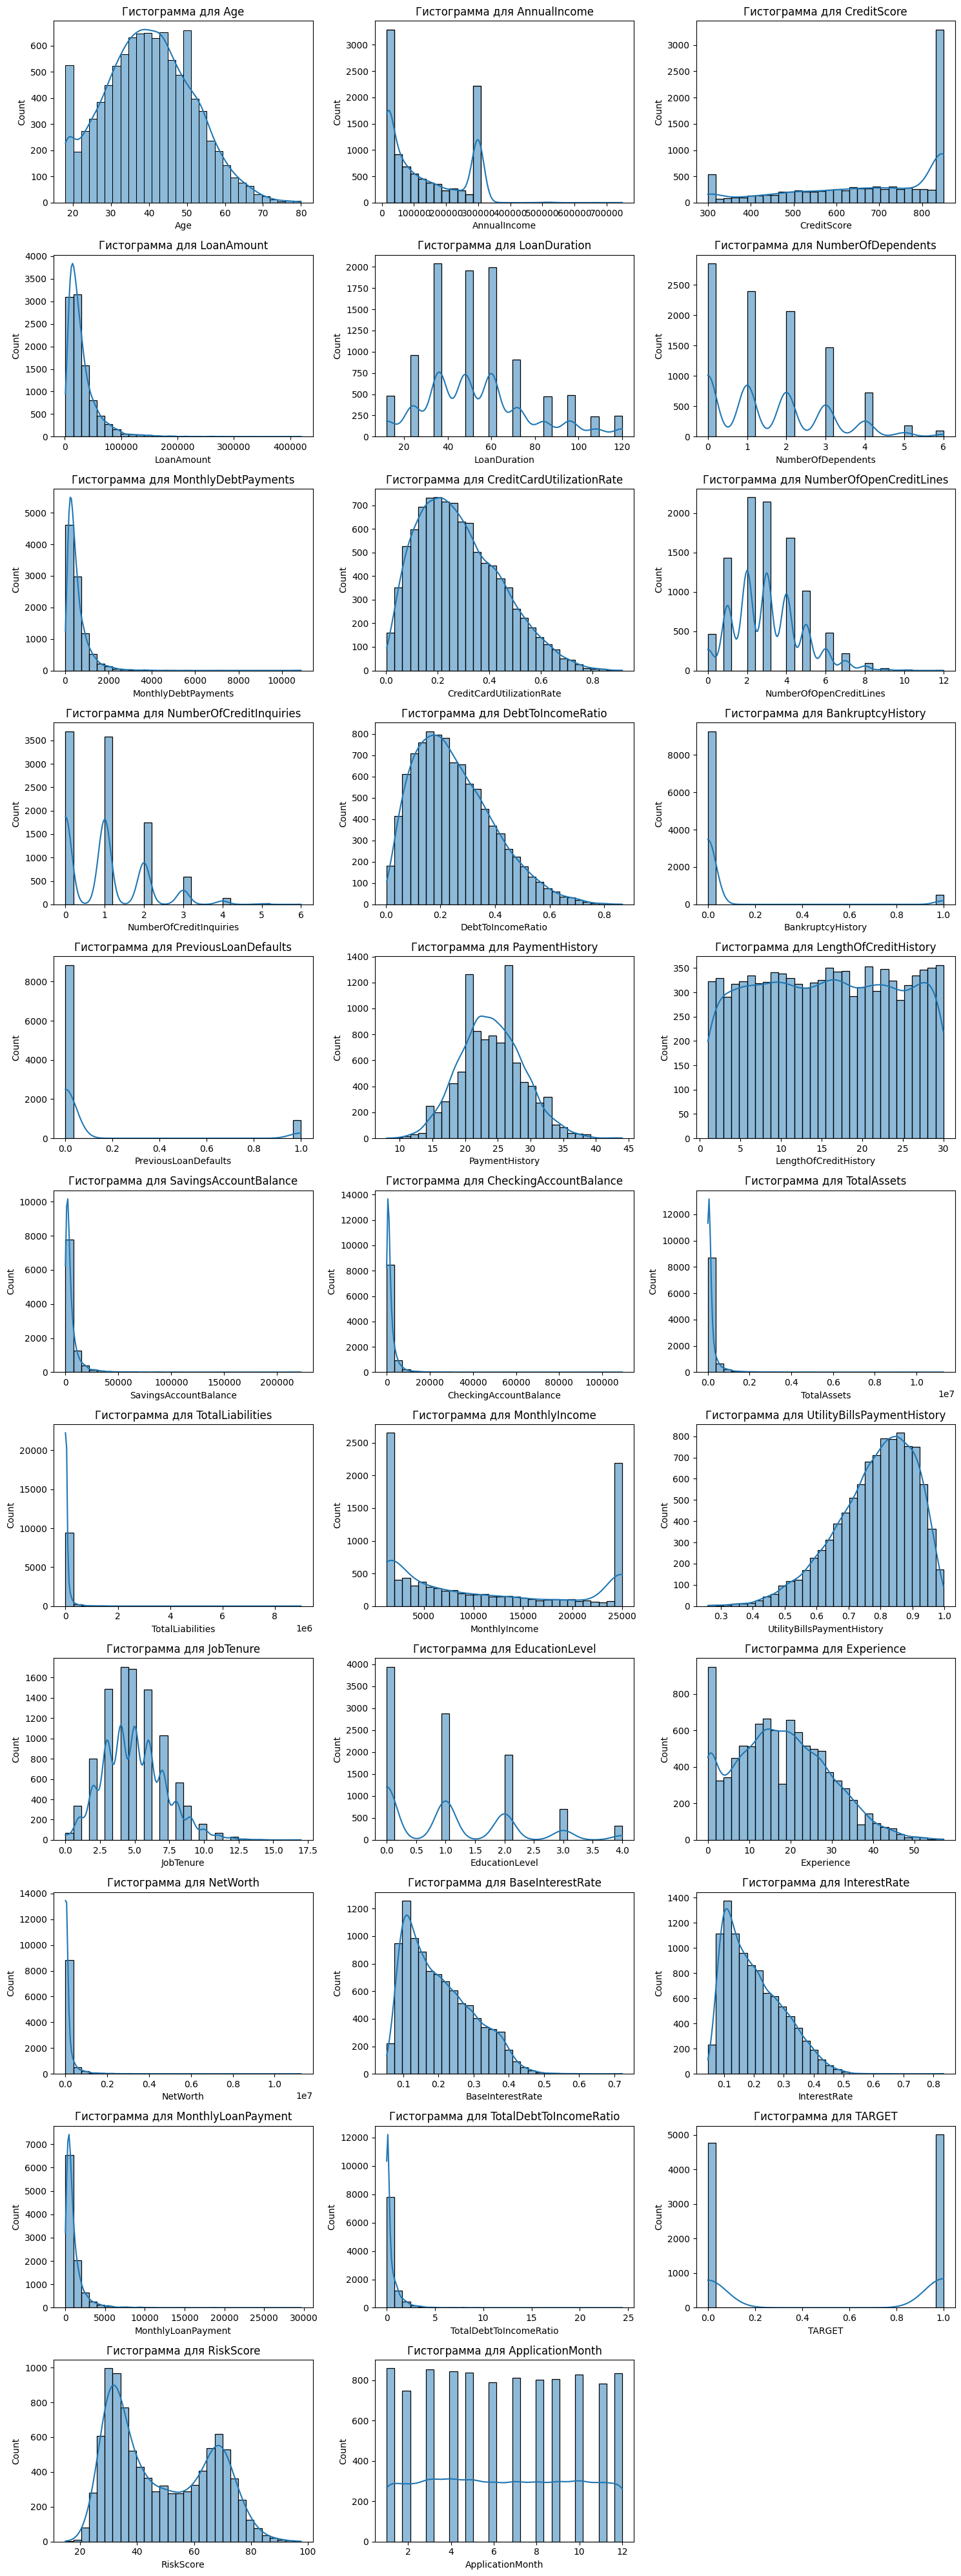

In [ ]:
num_col = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(15, 40))
for i, col in enumerate(num_col, 1):
    plt.subplot(len(num_col)//3 + 1, 3, i)
    sns.histplot(train_df[col], bins=30, kde=True)
    plt.title(f'Гистограмма для {col}')
    plt.tight_layout()

plt.show()

### Наиболее релевантные для обучения признаки

In [ ]:
columns_data = [
    'CreditScore', 'LoanDuration', 'MonthlyDebtPayments', 'BankruptcyHistory',
    'PreviousLoanDefaults', 'LengthOfCreditHistory', 'MonthlyIncome',
    'EducationLevel', 'Experience', 'NetWorth', 'BaseInterestRate',
    'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'
]
train_data = train_df[columns_data].copy(deep=True)

In [ ]:
def compute_and_display_classification_performance(true_labels, predicted_labels, classifier_name):
    precision_value = precision_score(true_labels, predicted_labels)
    recall_value = recall_score(true_labels, predicted_labels)
    f1_value = f1_score(true_labels, predicted_labels)
    accuracy_value = accuracy_score(true_labels, predicted_labels)
    performance_results = {
        'Precision': precision_value,
        'Recall': recall_value,
        'F1_Score': f1_value,
        'Accuracy': accuracy_value
    }
    print(f"Performance metrics for classifier '{classifier_name}':")
    for metric_name, metric_value in performance_results.items():
        print(f"  {metric_name}: {metric_value:.4f}")
    confusion_mat = confusion_matrix(true_labels, predicted_labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='coolwarm', linewidths=0.5, ax=ax)
    ax.set_title(f"Confusion Matrix - {classifier_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()
    return performance_results


### Самописный класс

In [ ]:
class GeneralizedClassifier:
    def __init__(self, lr=0.01, epochs=1000, use_logistic=False):
        self.lr = lr
        self.epochs = epochs
        self.use_logistic = use_logistic
        self.coefficients = None
        self.intercept = None

    def _activation_function(self, value):
        return 1 / (1 + np.exp(-value))

    def fit(self, features, labels):
        num_samples, num_features = features.shape
        self.coefficients = np.zeros(num_features)
        self.intercept = 0

        for _ in range(self.epochs):
            linear_output = np.dot(features, self.coefficients) + self.intercept

            if self.use_logistic:
                predictions = self._activation_function(linear_output)
                gradient_weights = (1 / num_samples) * np.dot(features.T, (predictions - labels))
                gradient_intercept = (1 / num_samples) * np.sum(predictions - labels)
            else:
                predictions = linear_output
                gradient_weights = (1 / num_samples) * np.dot(features.T, (predictions - labels))
                gradient_intercept = (1 / num_samples) * np.sum(predictions - labels)

            self.coefficients -= self.lr * gradient_weights
            self.intercept -= self.lr * gradient_intercept

    def predict(self, features):
        linear_output = np.dot(features, self.coefficients) + self.intercept

        if self.use_logistic:
            probabilities = self._activation_function(linear_output)
            return np.where(probabilities >= 0.5, 1, 0)
        else:
            return np.where(linear_output >= 0.5, 1, 0)

In [ ]:
X = train_data[columns_data]
y = train_df['TARGET']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 1) Самописная Logistic Regression

Performance metrics for classifier 'Custom Logistic Regression':
  Precision: 0.9253
  Recall: 0.9670
  F1_Score: 0.9457
  Accuracy: 0.9433


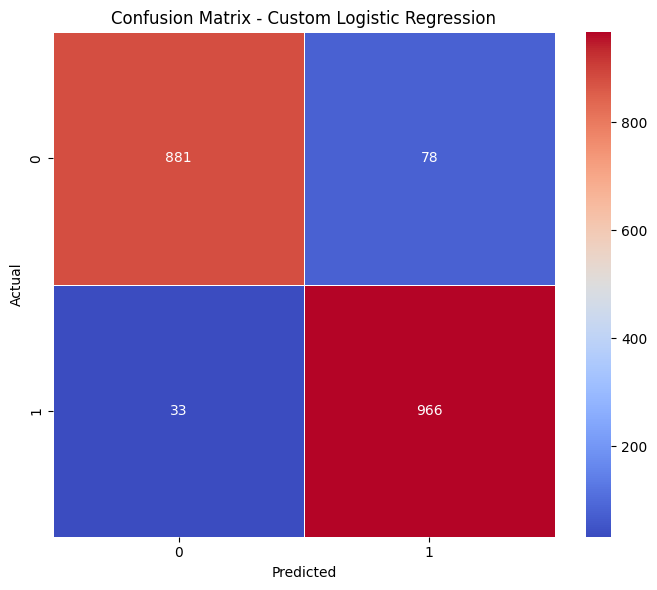

{'Precision': 0.9252873563218391,
 'Recall': 0.9669669669669669,
 'F1_Score': 0.9456681350954479,
 'Accuracy': 0.9433094994892748}

In [ ]:
logistic_model = GeneralizedClassifier(lr=0.01, epochs=1000, use_logistic=True)
logistic_model.fit(X_train_scaled, y_train)
y_pred_logistic = logistic_model.predict(X_test_scaled)
compute_and_display_classification_performance(y_test, y_pred_logistic, "Custom Logistic Regression")


## 1) Самописная Linear Classificator

Performance metrics for classifier 'Custom Linear Classificator':
  Precision: 0.9772
  Recall: 0.9850
  F1_Score: 0.9811
  Accuracy: 0.9806


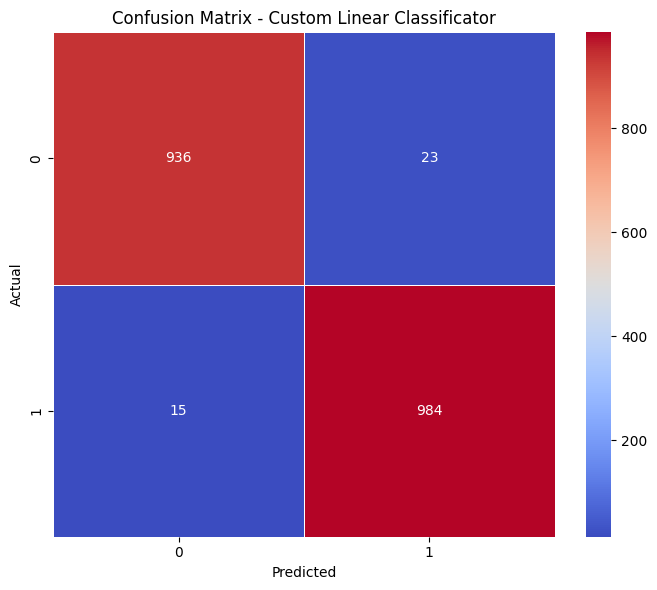

{'Precision': 0.9771598808341608,
 'Recall': 0.984984984984985,
 'F1_Score': 0.9810568295114656,
 'Accuracy': 0.9805924412665986}

In [ ]:
linear_reg_model = GeneralizedClassifier(lr=0.01, epochs=1000, use_logistic=False)
linear_reg_model.fit(X_train_scaled, y_train)
y_pred_linear_reg = linear_reg_model.predict(X_test_scaled)
compute_and_display_classification_performance(y_test, y_pred_linear_reg, "Custom Linear Classificator")

### 2) Sklearn Linear Classificator

Performance metrics for classifier 'Sklearn Linear Classificator':
  Precision: 0.9861
  Recall: 0.9940
  F1_Score: 0.9900
  Accuracy: 0.9898


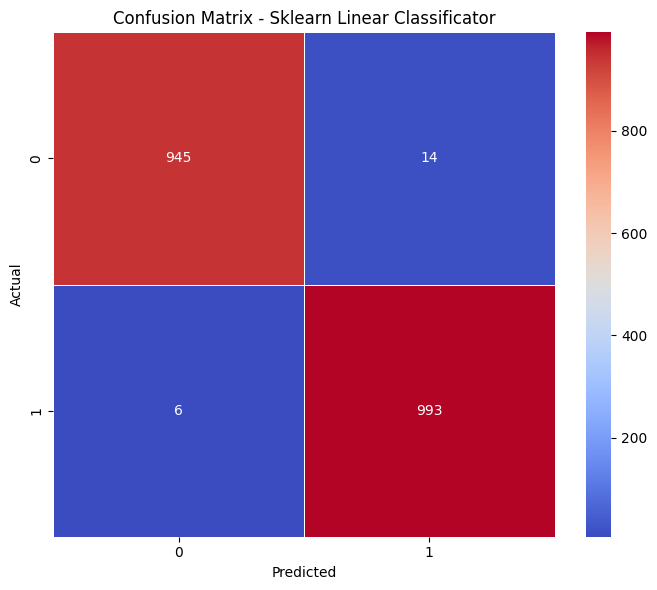

{'Precision': 0.9860973187686196,
 'Recall': 0.993993993993994,
 'F1_Score': 0.9900299102691924,
 'Accuracy': 0.9897854954034729}

In [ ]:
model_log_reg_sklearn = LogisticRegression()
model_log_reg_sklearn.fit(X_train_scaled, y_train)
y_pred_log_reg_sklearn = model_log_reg_sklearn.predict(X_test_scaled)
compute_and_display_classification_performance(y_test, y_pred_log_reg_sklearn, "Sklearn Linear Classificator")

### 2) Decision Tree Classificator

Performance metrics for classifier 'Decision Tree Classificator':
  Precision: 0.9800
  Recall: 0.9820
  F1_Score: 0.9810
  Accuracy: 0.9806


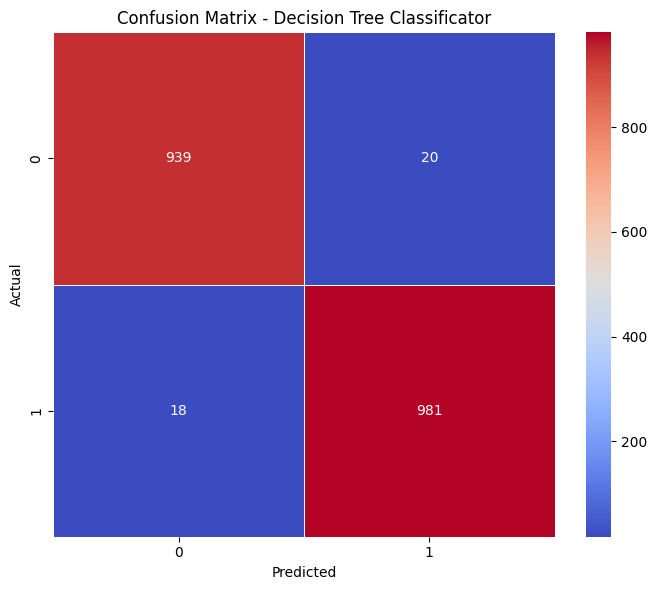

{'Precision': 0.98001998001998,
 'Recall': 0.9819819819819819,
 'F1_Score': 0.981,
 'Accuracy': 0.9805924412665986}

In [ ]:
model_DecisionTreeClassifier = DecisionTreeClassifier()
model_DecisionTreeClassifier.fit(X_train, y_train)
y_pred_model_DecisionTreeClassifier = model_DecisionTreeClassifier.predict(X_test)
compute_and_display_classification_performance(y_test, y_pred_model_DecisionTreeClassifier, "Decision Tree Classificator")

### 2) Random ForestGamp Classificator

Performance metrics for classifier 'Random ForestGamp Classificator':
  Precision: 0.9851
  Recall: 0.9910
  F1_Score: 0.9880
  Accuracy: 0.9877


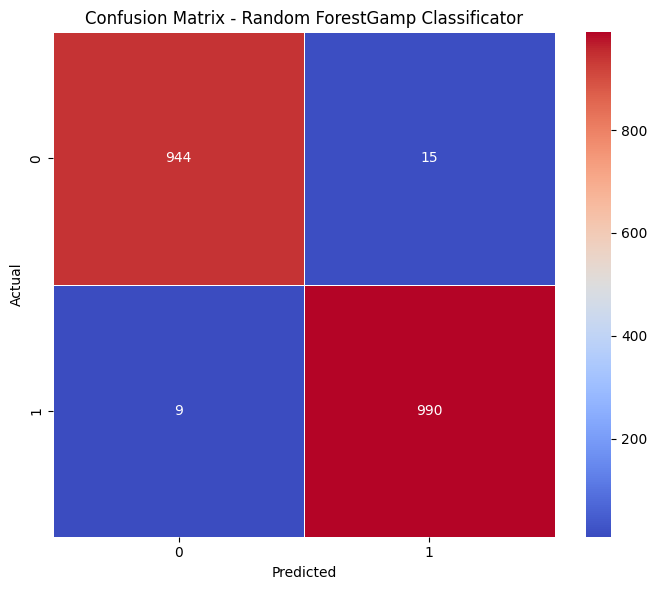

{'Precision': 0.9850746268656716,
 'Recall': 0.990990990990991,
 'F1_Score': 0.9880239520958084,
 'Accuracy': 0.9877425944841676}

In [ ]:
model_RandomForestClassifier = RandomForestClassifier()
model_RandomForestClassifier.fit(X_train, y_train)
y_pred_model_RandomForestClassifier = model_RandomForestClassifier.predict(X_test)
compute_and_display_classification_performance(y_test, y_pred_model_RandomForestClassifier, "Random ForestGamp Classificator")

### 2) Boosting: Sklearn boost, LightGBM, XGBoost, CatBoost

Performance metrics for classifier 'Sklearn Gradient Boosting':
  Precision: 0.9860
  Recall: 0.9890
  F1_Score: 0.9875
  Accuracy: 0.9872


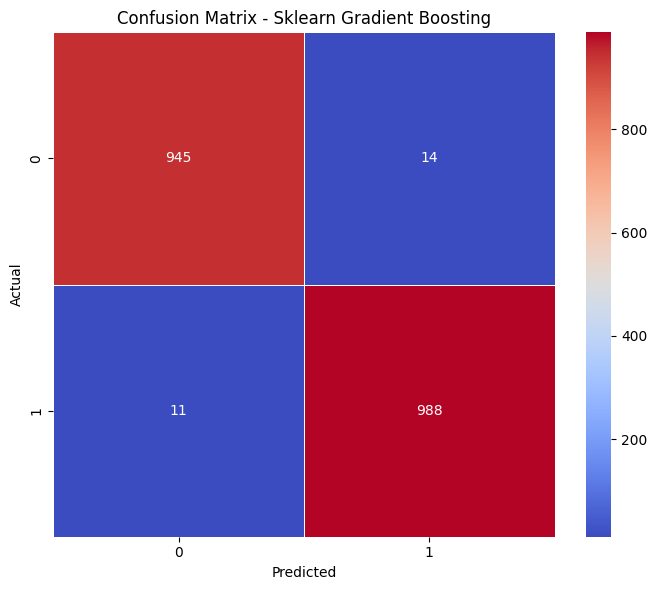

{'Precision': 0.9860279441117764,
 'Recall': 0.988988988988989,
 'F1_Score': 0.9875062468765617,
 'Accuracy': 0.9872318692543411}

In [ ]:
sklearn_gb_model = GradientBoostingClassifier(random_state=42)
sklearn_gb_model.fit(X_train, y_train)
y_pred_sklearn_gb = sklearn_gb_model.predict(X_test)
compute_and_display_classification_performance(y_test, y_pred_sklearn_gb, "Sklearn Gradient Boosting")

[LightGBM] [Info] Number of positive: 4013, number of negative: 3816
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2136
[LightGBM] [Info] Number of data points in the train set: 7829, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512581 -> initscore=0.050336
[LightGBM] [Info] Start training from score 0.050336
Performance metrics for classifier 'LightGBM':
  Precision: 0.9910
  Recall: 0.9900
  F1_Score: 0.9905
  Accuracy: 0.9903


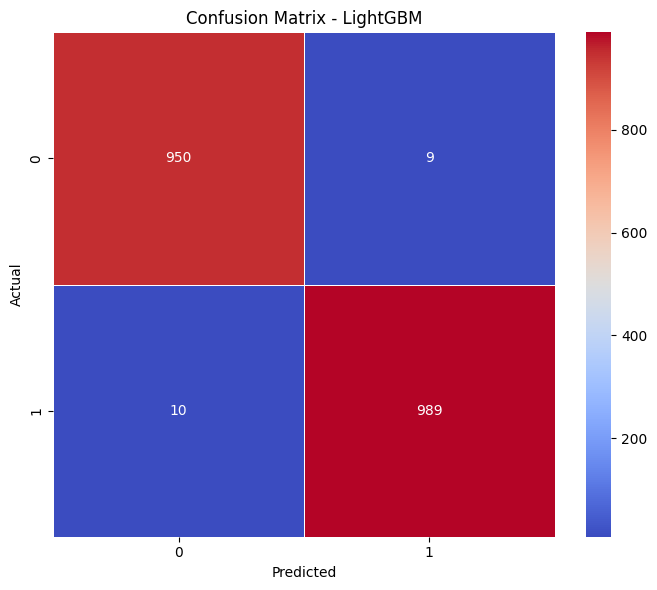

{'Precision': 0.9909819639278558,
 'Recall': 0.98998998998999,
 'F1_Score': 0.9904857285928893,
 'Accuracy': 0.9902962206332993}

In [ ]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
compute_and_display_classification_performance(y_test, y_pred_lgb, "LightGBM")

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:15:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Performance metrics for classifier 'XGBoost':
  Precision: 0.9930
  Recall: 0.9920
  F1_Score: 0.9925
  Accuracy: 0.9923


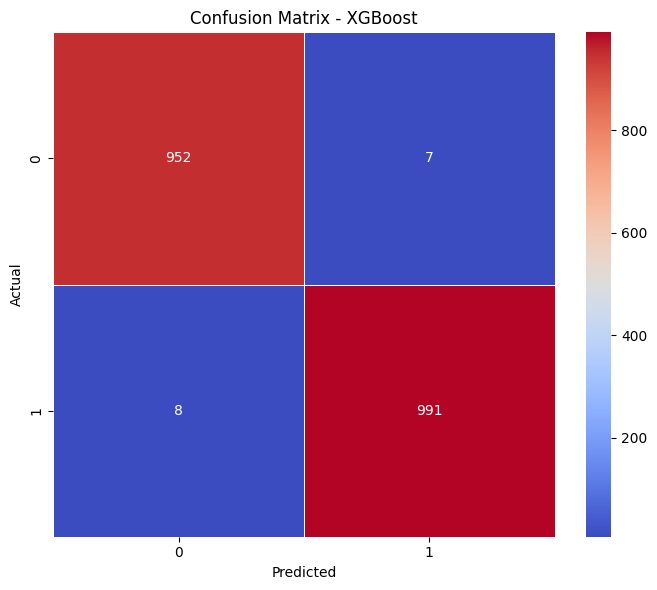

{'Precision': 0.9929859719438878,
 'Recall': 0.991991991991992,
 'F1_Score': 0.9924887330996495,
 'Accuracy': 0.9923391215526047}

In [ ]:
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
compute_and_display_classification_performance(y_test, y_pred_xgb, "XGBoost")

Performance metrics for classifier 'CatBoost':
  Precision: 0.9940
  Recall: 0.9920
  F1_Score: 0.9930
  Accuracy: 0.9928


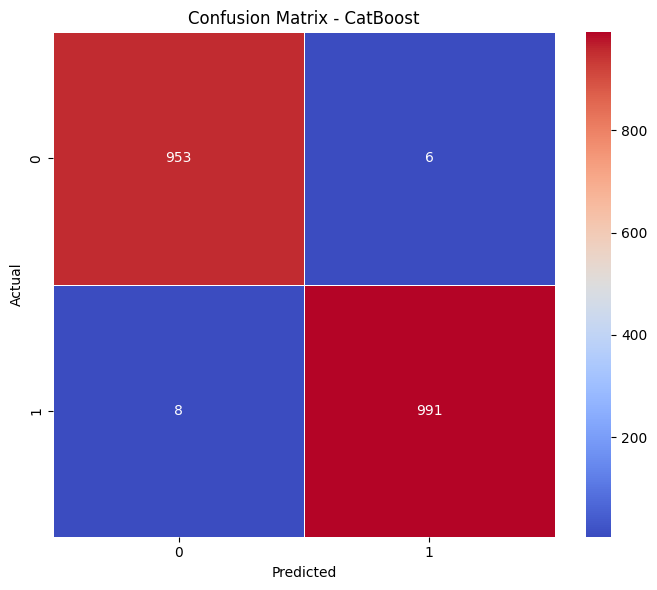

{'Precision': 0.9939819458375125,
 'Recall': 0.991991991991992,
 'F1_Score': 0.9929859719438878,
 'Accuracy': 0.992849846782431}

In [ ]:
catboost_model = CatBoostClassifier(random_state=42, verbose=0)
catboost_model.fit(X_train, y_train)
y_pred_catboost = catboost_model.predict(X_test)
compute_and_display_classification_performance(y_test, y_pred_catboost, "CatBoost")

### KNeighborsClassifier

Performance metrics for classifier 'K-Nearest Neighbors':
  Precision: 0.8691
  Recall: 0.8909
  F1_Score: 0.8799
  Accuracy: 0.8759


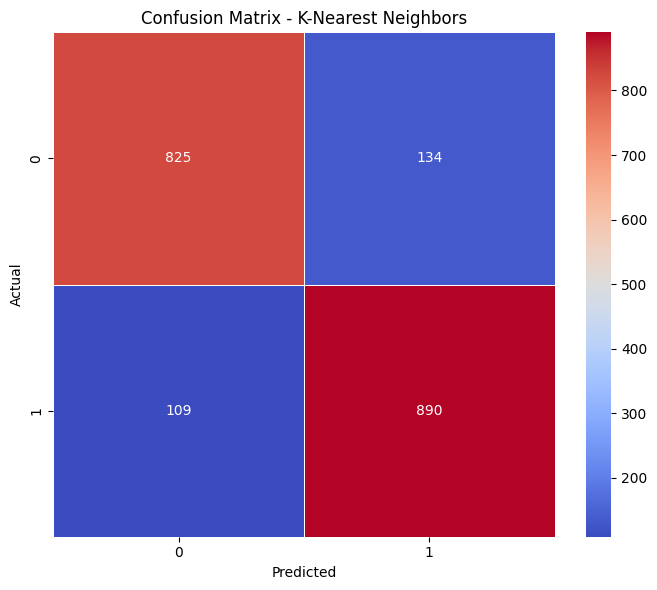

{'Precision': 0.869140625,
 'Recall': 0.8908908908908909,
 'F1_Score': 0.8798813643104301,
 'Accuracy': 0.8758937691521961}

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
compute_and_display_classification_performance(y_test, y_pred_knn, "K-Nearest Neighbors")

### AdaBoost

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Performance metrics for classifier 'AdaBoost':
  Precision: 0.9910
  Recall: 0.9900
  F1_Score: 0.9905
  Accuracy: 0.9903


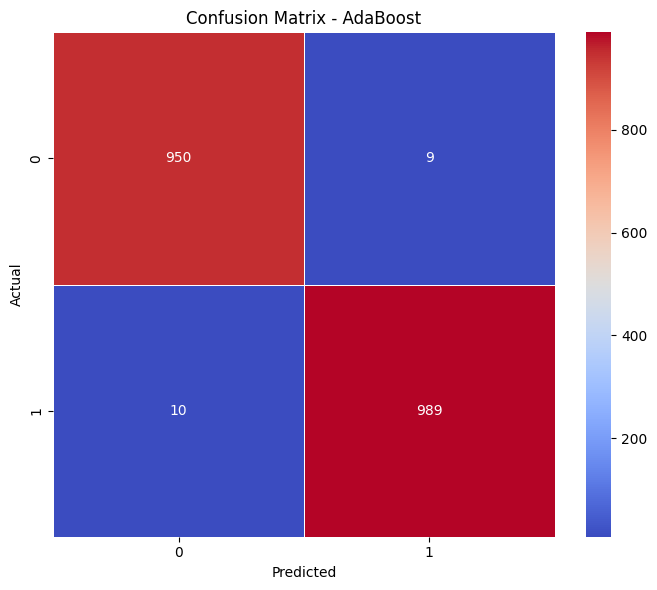

{'Precision': 0.9909819639278558,
 'Recall': 0.98998998998999,
 'F1_Score': 0.9904857285928893,
 'Accuracy': 0.9902962206332993}

In [ ]:
adaboost_model = AdaBoostClassifier(random_state=42, n_estimators=100)
adaboost_model.fit(X_train, y_train)
y_pred_adaboost = adaboost_model.predict(X_test)
compute_and_display_classification_performance(y_test, y_pred_adaboost, "AdaBoost")


## Вывод

Анализ результатов показал, что лидерами по производительности являются ансамблевые методы, такие как CatBoost и XGBoost, что связано с их способностью эффективно работать с сложными зависимостями в данных. При этом Logistic Regression из sklearn продемонстрировала конкурентоспособные результаты, что указывает на линейную разделимость набора данных. Меньшую эффективность показали простые модели, такие как Decision Tree, что обусловлено отсутствием ограничений глубины и склонностью к переобучению.
Сравнение методов бустинга выявило превосходство CatBoost, который благодаря оптимизациям алгоритма сопоставим с Logistic Regression. Среди других методов, Random Forest и SVC показали уверенные результаты, но уступили бустинговым моделям. Разница между LightGBM и XGBoost заключается в подходе к построению деревьев: первый точнее на больших данных, второй — более отзывчив.

При оценке моделей F1-мера и точность оказались ключевыми метриками, однако для детального анализа также учитывались precision и recall. Использование confusion matrix подтвердило отсутствие значительных ошибок модели и сбалансированность предсказаний.